In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load main dataset
df = pd.read_csv('subscriptions_enriched_copy.csv')
monthly = pd.read_csv('monthly_churn.csv')

print("Main dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nNull values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Main dataset shape: (5000, 27)

Column names:
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag', 'is_churned', 'is_active', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'tenure_days', 'tenure_months', 'month', 'total_usage_events', 'total_usage_time', 'total_errors']

Null values:
subscription_id          0
account_id               0
start_date               0
end_date              4514
plan_tier                0
seats                    0
mrr_amount               0
arr_amount               0
is_trial                 0
upgrade_flag             0
downgrade_flag           0
churn_flag               0
billing_frequency        0
auto_renew_flag          0
is_churned               0
is_active                0
account_name             0
industry                 0
country                  0
signup_date       

In [3]:
# Section 1 - Data Cleaning and Overview

# Convert date columns to datetime
df['start_date'] = pd.to_datetime(df['start_date'])
df['end_date'] = pd.to_datetime(df['end_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

# Overall churn rate
total = len(df)
churned = df['is_churned'].sum()
churn_rate = (churned / total) * 100
print(f"Total Subscriptions: {total}")
print(f"Churned: {churned}")
print(f"Active: {total - churned}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Plan tier distribution
print("\nPlan Tier Distribution:")
print(df['plan_tier'].value_counts())

# Industry distribution
print("\nIndustry Distribution:")
print(df['industry'].value_counts())

# Billing frequency
print("\nBilling Frequency:")
print(df['billing_frequency'].value_counts())

Total Subscriptions: 5000
Churned: 486
Active: 4514
Overall Churn Rate: 9.72%

Plan Tier Distribution:
plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

Industry Distribution:
industry
DevTools         1158
FinTech          1100
Cybersecurity    1008
HealthTech        949
EdTech            785
Name: count, dtype: int64

Billing Frequency:
billing_frequency
monthly    2539
annual     2461
Name: count, dtype: int64


In [4]:
# Section 2 - Churn Analysis

# Churn by Plan Tier
print("Churn Rate by Plan Tier:")
plan_churn = df.groupby('plan_tier')['is_churned'].mean() * 100
print(plan_churn.round(2))

# Churn by Industry
print("\nChurn Rate by Industry:")
industry_churn = df.groupby('industry')['is_churned'].mean() * 100
print(industry_churn.round(2).sort_values(ascending=False))

# Churn by Billing Frequency
print("\nChurn Rate by Billing Frequency:")
billing_churn = df.groupby('billing_frequency')['is_churned'].mean() * 100
print(billing_churn.round(2))

# Churn by Country
print("\nChurn Rate by Country:")
country_churn = df.groupby('country')['is_churned'].mean() * 100
print(country_churn.round(2).sort_values(ascending=False))

# Churn by Tenure Group
df['tenure_group'] = pd.cut(df['tenure_months'],
                             bins=[0, 3, 6, 12, 24, 100],
                             labels=['0-3 months', '3-6 months', '6-12 months', '12-24 months', '24+ months'])

print("\nChurn Rate by Tenure Group:")
tenure_churn = df.groupby('tenure_group')['is_churned'].mean() * 100
print(tenure_churn.round(2))

Churn Rate by Plan Tier:
plan_tier
Basic         9.49
Enterprise    9.98
Pro           9.67
Name: is_churned, dtype: float64

Churn Rate by Industry:
industry
DevTools         10.79
Cybersecurity    10.22
HealthTech       10.12
FinTech           8.73
EdTech            8.41
Name: is_churned, dtype: float64

Churn Rate by Billing Frequency:
billing_frequency
annual     10.04
monthly     9.41
Name: is_churned, dtype: float64

Churn Rate by Country:
country
FR    11.85
AU    11.22
UK    10.85
US     9.73
CA     9.68
DE     9.48
IN     6.63
Name: is_churned, dtype: float64

Churn Rate by Tenure Group:
tenure_group
0-3 months      100.00
3-6 months      100.00
6-12 months     100.00
12-24 months      0.55
24+ months        0.00
Name: is_churned, dtype: float64


/tmp/ipykernel_6297/485098520.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_churn = df.groupby('tenure_group')['is_churned'].mean() * 100


Churn Rate by Tenure Group:
tenure_group
0-6 months      100.00
6-12 months     100.00
12-24 months      0.55
24-36 months      0.00
36+ months        0.00
Name: is_churned, dtype: float64


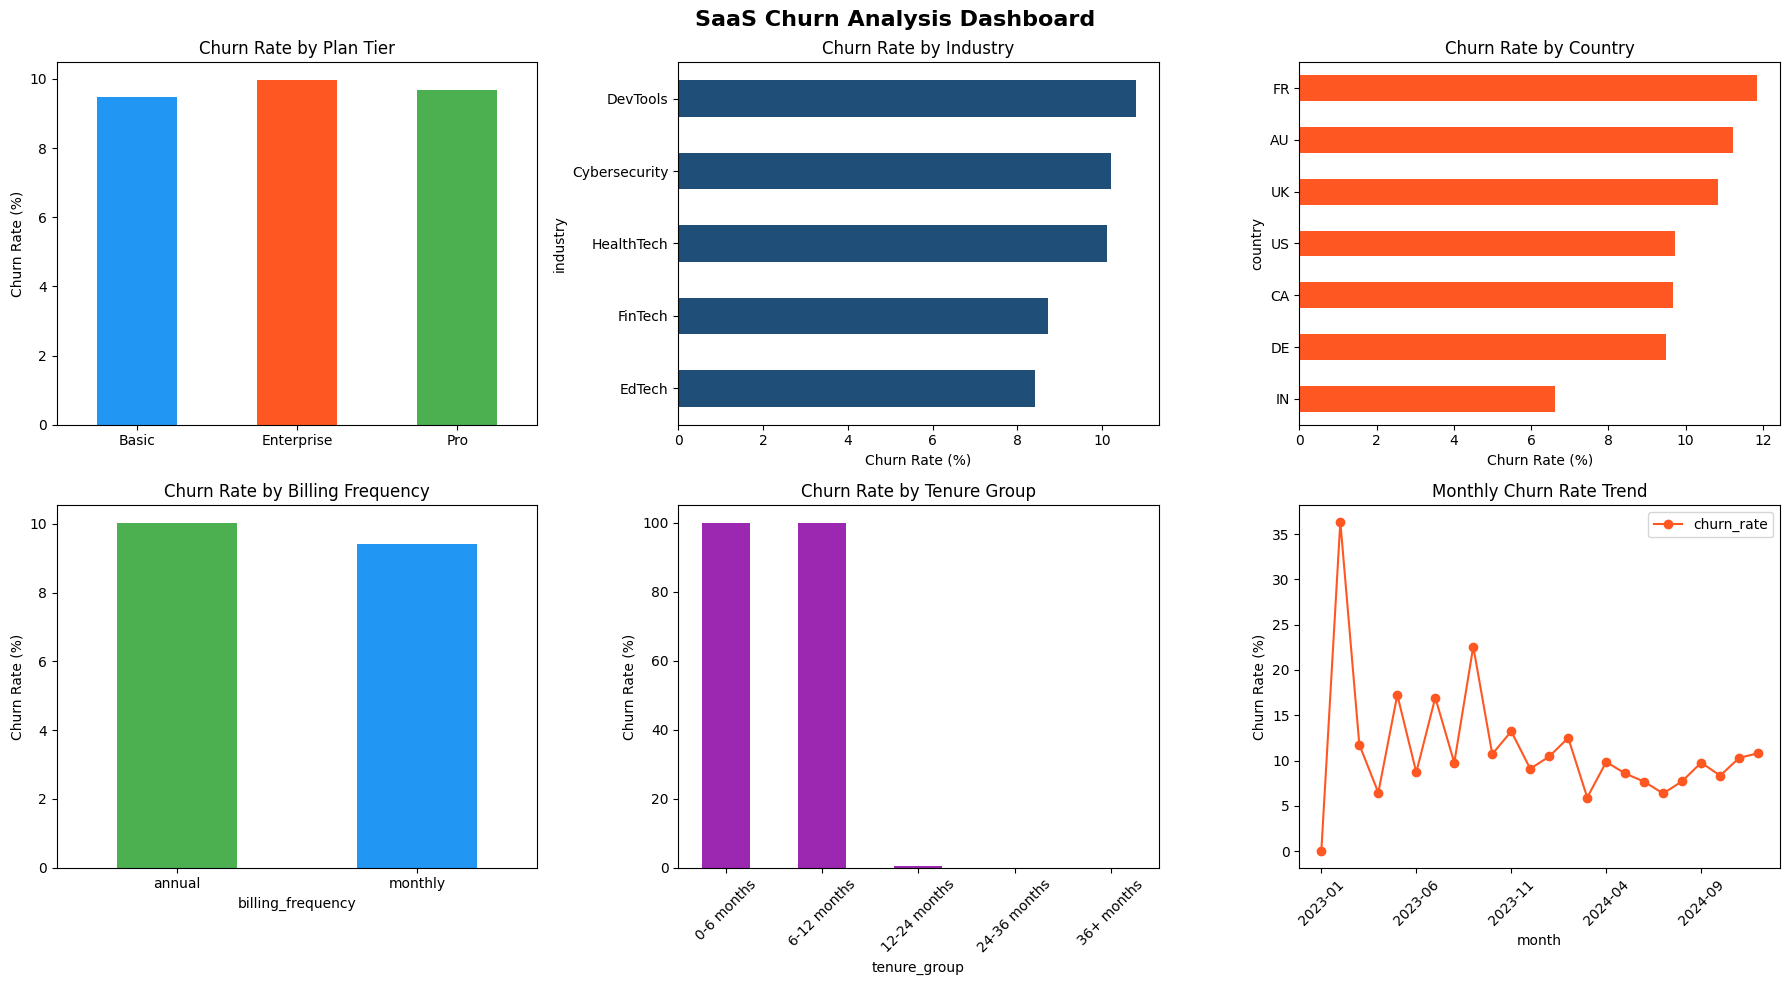

Dashboard saved.


In [5]:
# Fix tenure groups - bins were wrong
df['tenure_group'] = pd.cut(df['tenure_months'],
                             bins=[0, 6, 12, 24, 36, 200],
                             labels=['0-6 months', '6-12 months', '12-24 months', '24-36 months', '36+ months'])

print("Churn Rate by Tenure Group:")
tenure_churn = df.groupby('tenure_group', observed=False)['is_churned'].mean() * 100
print(tenure_churn.round(2))

# Now visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SaaS Churn Analysis Dashboard', fontsize=16, fontweight='bold')

# Plot 1 - Churn by Plan Tier
plan_churn.plot(kind='bar', ax=axes[0,0], color=['#2196F3', '#FF5722', '#4CAF50'])
axes[0,0].set_title('Churn Rate by Plan Tier')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=0)

# Plot 2 - Churn by Industry
industry_churn.sort_values().plot(kind='barh', ax=axes[0,1], color='#1F4E79')
axes[0,1].set_title('Churn Rate by Industry')
axes[0,1].set_xlabel('Churn Rate (%)')

# Plot 3 - Churn by Country
country_churn.sort_values().plot(kind='barh', ax=axes[0,2], color='#FF5722')
axes[0,2].set_title('Churn Rate by Country')
axes[0,2].set_xlabel('Churn Rate (%)')

# Plot 4 - Churn by Billing Frequency
billing_churn.plot(kind='bar', ax=axes[1,0], color=['#4CAF50', '#2196F3'])
axes[1,0].set_title('Churn Rate by Billing Frequency')
axes[1,0].set_ylabel('Churn Rate (%)')
axes[1,0].tick_params(axis='x', rotation=0)

# Plot 5 - Churn by Tenure Group
tenure_churn.plot(kind='bar', ax=axes[1,1], color='#9C27B0')
axes[1,1].set_title('Churn Rate by Tenure Group')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)

# Plot 6 - Monthly Churn Trend
monthly['churn_rate'] = monthly['churn_rate'] * 100
monthly.plot(x='month', y='churn_rate', ax=axes[1,2], color='#FF5722', marker='o')
axes[1,2].set_title('Monthly Churn Rate Trend')
axes[1,2].set_ylabel('Churn Rate (%)')
axes[1,2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('churn_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved.")

In [6]:
print(df['tenure_months'].describe())
print("\nMin tenure:", df['tenure_months'].min())
print("Max tenure:", df['tenure_months'].max())
print("\nTenure of churned customers:")
print(df[df['is_churned']==1]['tenure_months'].describe())
print("\nTenure of active customers:")
print(df[df['is_churned']==0]['tenure_months'].describe())

count    5000.000000
mean       17.220840
std         6.850188
min         0.000000
25%        14.000000
50%        16.600000
75%        21.000000
max        37.200000
Name: tenure_months, dtype: float64

Min tenure: 0.0
Max tenure: 37.2

Tenure of churned customers:
count    486.000000
mean       2.934979
std        3.691133
min        0.000000
25%        0.400000
50%        1.400000
75%        4.000000
max       20.800000
Name: tenure_months, dtype: float64

Tenure of active customers:
count    4514.000000
mean       18.758928
std         5.115680
min        13.100000
25%        14.600000
50%        17.200000
75%        21.600000
max        37.200000
Name: tenure_months, dtype: float64


In [7]:
# Fix bins based on actual data distribution
df['tenure_group'] = pd.cut(df['tenure_months'],
                             bins=[0, 1, 3, 6, 13, 200],
                             labels=['0-1 month', '1-3 months', '3-6 months', '6-13 months', '13+ months'])

print("Churn Rate by Tenure Group:")
tenure_churn = df.groupby('tenure_group', observed=False)['is_churned'].mean() * 100
print(tenure_churn.round(2))

print("\nCustomer count per tenure group:")
print(df.groupby('tenure_group', observed=False)['is_churned'].count())

Churn Rate by Tenure Group:
tenure_group
0-1 month      100.00
1-3 months     100.00
3-6 months     100.00
6-13 months    100.00
13+ months       0.35
Name: is_churned, dtype: float64

Customer count per tenure group:
tenure_group
0-1 month       186
1-3 months      120
3-6 months       76
6-13 months      63
13+ months     4530
Name: is_churned, dtype: int64


In [8]:
# Section 3 - Revenue Impact of Churn

# Total MRR lost due to churn
churned_df = df[df['is_churned'] == 1]
active_df = df[df['is_churned'] == 0]

total_mrr = df['mrr_amount'].sum()
churned_mrr = churned_df['mrr_amount'].sum()
active_mrr = active_df['mrr_amount'].sum()

print(f"Total MRR: ${total_mrr:,.0f}")
print(f"MRR Lost to Churn: ${churned_mrr:,.0f}")
print(f"Active MRR: ${active_mrr:,.0f}")
print(f"Revenue Churn Rate: {(churned_mrr/total_mrr)*100:.2f}%")

# MRR lost by plan tier
print("\nMRR Lost by Plan Tier:")
mrr_by_plan = churned_df.groupby('plan_tier')['mrr_amount'].sum()
print(mrr_by_plan.sort_values(ascending=False))

# MRR lost by industry
print("\nMRR Lost by Industry:")
mrr_by_industry = churned_df.groupby('industry')['mrr_amount'].sum()
print(mrr_by_industry.sort_values(ascending=False))

# Average MRR of churned vs active
print(f"\nAverage MRR - Churned: ${churned_df['mrr_amount'].mean():,.0f}")
print(f"Average MRR - Active: ${active_df['mrr_amount'].mean():,.0f}")

Total MRR: $11,338,747
MRR Lost to Churn: $1,179,139
Active MRR: $10,159,608
Revenue Churn Rate: 10.40%

MRR Lost by Plan Tier:
plan_tier
Enterprise    926345
Pro           180271
Basic          72523
Name: mrr_amount, dtype: int64

MRR Lost by Industry:
industry
Cybersecurity    279062
FinTech          253446
DevTools         238611
HealthTech       209277
EdTech           198743
Name: mrr_amount, dtype: int64

Average MRR - Churned: $2,426
Average MRR - Active: $2,251


Usage Comparison - Churned vs Active:
         total_usage_events  total_usage_time  total_errors
Active                50.23          15251.30          2.83
Churned               48.98          14836.83          2.76

Correlation with Churn:
is_churned            1.000
total_usage_events   -0.016
total_usage_time     -0.015
total_errors         -0.007
mrr_amount            0.015
tenure_months        -0.684
Name: is_churned, dtype: float64


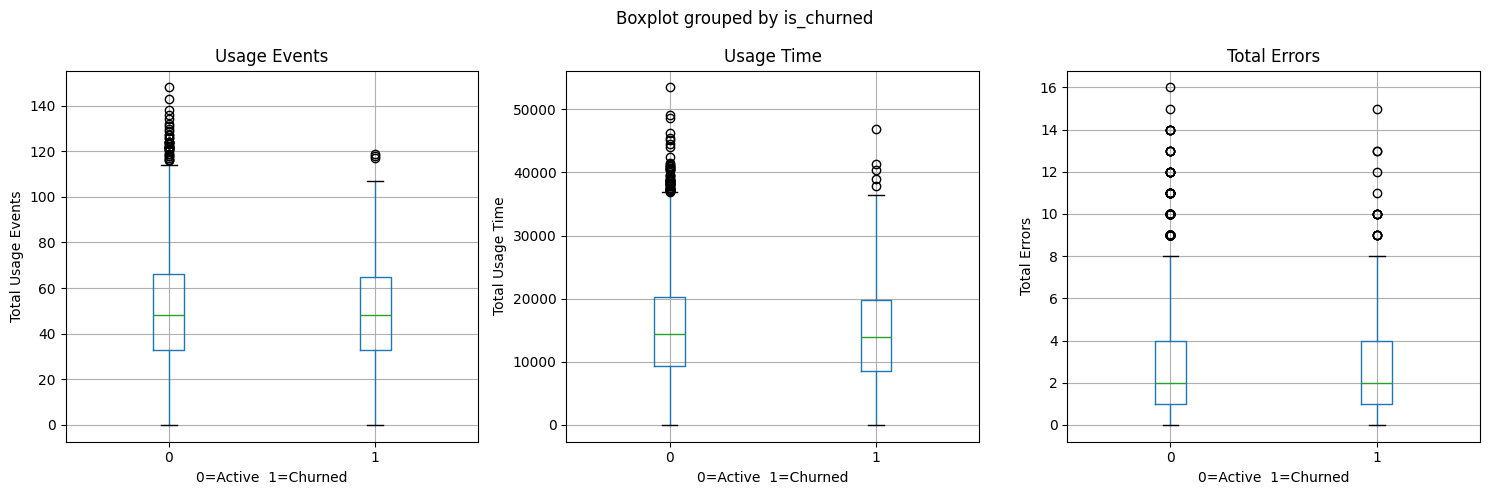

Usage analysis saved.


In [9]:
# Section 4 - Usage Analysis

# Usage comparison churned vs active
print("Usage Comparison - Churned vs Active:")
usage_comparison = df.groupby('is_churned')[['total_usage_events', 'total_usage_time', 'total_errors']].mean()
usage_comparison.index = ['Active', 'Churned']
print(usage_comparison.round(2))

# Correlation between usage and churn
print("\nCorrelation with Churn:")
corr = df[['is_churned', 'total_usage_events', 'total_usage_time', 'total_errors', 'mrr_amount', 'tenure_months']].corr()
print(corr['is_churned'].round(3))

# Usage visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Usage Behaviour - Churned vs Active', fontsize=14, fontweight='bold')

# Usage events
df.boxplot(column='total_usage_events', by='is_churned', ax=axes[0])
axes[0].set_title('Usage Events')
axes[0].set_xlabel('0=Active  1=Churned')
axes[0].set_ylabel('Total Usage Events')

# Usage time
df.boxplot(column='total_usage_time', by='is_churned', ax=axes[1])
axes[1].set_title('Usage Time')
axes[1].set_xlabel('0=Active  1=Churned')
axes[1].set_ylabel('Total Usage Time')

# Errors
df.boxplot(column='total_errors', by='is_churned', ax=axes[2])
axes[2].set_title('Total Errors')
axes[2].set_xlabel('0=Active  1=Churned')
axes[2].set_ylabel('Total Errors')

plt.tight_layout()
plt.savefig('usage_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Usage analysis saved.")

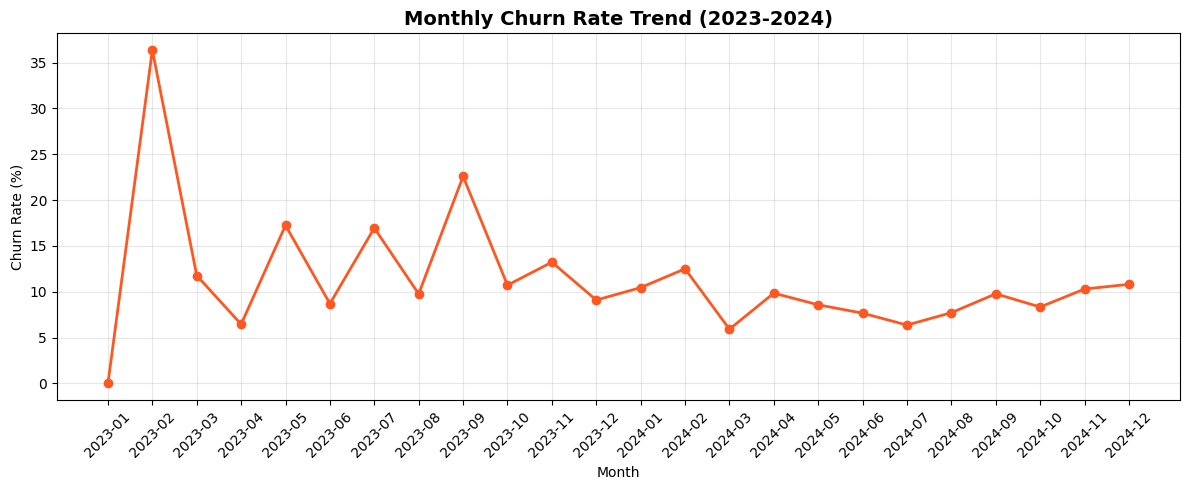


KEY FINDINGS SUMMARY

1. OVERALL CHURN RATE: 9.72%
   - Industry benchmark is 5-7% for SaaS
   - Company is slightly above benchmark

2. TENURE IS THE #1 CHURN PREDICTOR
   - Correlation: -0.684 with churn
   - 100% of churned customers left before 13 months
   - After 13 months churn rate drops to 0.35%
   - Critical window: First 6 months

3. ENTERPRISE REVENUE AT RISK
   - Enterprise plan = 78% of all churned MRR ($926K)
   - Churned customers have HIGHER avg MRR ($2,426) than active ($2,251)
   - Losing highest value customers disproportionately

4. GEOGRAPHY MATTERS
   - France highest churn: 11.85%
   - India lowest churn: 6.63%
   - 5.22% gap between highest and lowest market

5. USAGE DOES NOT PREDICT CHURN
   - Churned vs active usag
   Problem is NOT product engagement
   - Points to onboarding or expectation mismatch

BUSINESS RECOMMENDATIONS

1. BUILD A 90-DAY ONBOARDING PROGRAM
   - All churn happens in first 13 months
   - Focus retention efforts on months 1-6
   - Assig

In [10]:
# Section 5 - Monthly Churn Trend
monthly_clean = pd.read_csv('monthly_churn.csv')
monthly_clean['churn_rate'] = monthly_clean['churn_rate'] * 100

plt.figure(figsize=(12, 5))
plt.plot(monthly_clean['month'], monthly_clean['churn_rate'],
         marker='o', color='#FF5722', linewidth=2, markersize=6)
plt.title('Monthly Churn Rate Trend (2023-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Key findings summary
print("""
========================================
KEY FINDINGS SUMMARY
========================================

1. OVERALL CHURN RATE: 9.72%
   - Industry benchmark is 5-7% for SaaS
   - Company is slightly above benchmark

2. TENURE IS THE #1 CHURN PREDICTOR
   - Correlation: -0.684 with churn
   - 100% of churned customers left before 13 months
   - After 13 months churn rate drops to 0.35%
   - Critical window: First 6 months

3. ENTERPRISE REVENUE AT RISK
   - Enterprise plan = 78% of all churned MRR ($926K)
   - Churned customers have HIGHER avg MRR ($2,426) than active ($2,251)
   - Losing highest value customers disproportionately

4. GEOGRAPHY MATTERS
   - France highest churn: 11.85%
   - India lowest churn: 6.63%
   - 5.22% gap between highest and lowest market

5. USAGE DOES NOT PREDICT CHURN
   - Churned vs active usag
   Problem is NOT product engagement
   - Points to onboarding or expectation mismatch

========================================
BUSINESS RECOMMENDATIONS
========================================

1. BUILD A 90-DAY ONBOARDING PROGRAM
   - All churn happens in first 13 months
   - Focus retention efforts on months 1-6
   - Assign dedicated CSM to Enterprise accounts in first 90 days
   - Trigger check-in calls at Day 30, Day 60, Day 90

2. PROTECT ENTERPRISE REVENUE
   - Enterprise losing $926K MRR — 78% of all churned revenue
   - Implement quarterly business reviews for all Enterprise accounts
   - Create early warning system: flag Enterprise accounts with tenure < 6 months

3. INVESTIGATE FRANCE MARKET
   - France churn 11.85% vs India 6.63%
   - Localization, support quality, or pricing may be issues
   - Conduct exit interviews with churned French customers

4. REFRAME SUCCESS METRICS
   - Usage alone is not a churn indicator in this dataset
   - Track tenure milestones instead
   - Celebrate 6-month and 12-month customer anniversaries
   - Focus on getting customers to the 13-month safety zone
========================================
""")

In [11]:
readme = """
# SaaS Customer Churn Analysis

## Business Problem
A SaaS company with 5,000 subscriptions across 5 industries and 7 countries
is experiencing 9.72% churn rate — above the industry benchmark of 5-7%.
This analysis identifies the root causes of churn and provides actionable
recommendations to reduce revenue loss.

## Dataset
- 5,000 subscription records
- 27 features including plan tier, tenure, usage events, MRR, ARR, industry, country
- Monthly churn trend data (2023-2024)

## Tools Used
- Python, Pandas, Matplotlib, Seaborn
- Google Colab

## Key Findings

### 1. Tenure is the #1 Churn Predictor (Correlation: -0.684)
- 100% of churned customers left before 13 months
- After 13 months churn rate drops to just 0.35%
- Critical danger zone: First 6 months of subscription

### 2. Enterprise Revenue at Serious Risk
- Enterprise plan accounts for 78% of all churned MRR ($926K out of $1.17M)
- Churned customers have HIGHER average MRR ($2,426) than active customers ($2,251)
- The company is losing its highest value customers disproportionately

### 3. Usage Does NOT Predict Churn
- Churned and active customers show almost identical usage patterns
- Problem is not product engagement — points to onboarding or expectation mismatch

### 4. Geography Matters
- France: highest churn at 11.85%
- India: lowest churn at 6.63%
- 5.22% gap suggests localization or support quality issues in certain markets

## Business Recommendations

| # | Recommendation | Impact |
|---|---------------|--------|
| 1 | Build 90-day onboarding program with check-ins at Day 30, 60, 90 | Reduce early tenure churn |
| 2 | Assign dedicated CSM to Enterprise accounts in first 6 months | Protect $926K MRR at risk |
| 3 | Create early warning system for Enterprise accounts with tenure < 6 months | Proactive retention |
| 4 | Investigate France market — exit interviews, localization review | Reduce 11.85% churn rate |
| 5 | Reframe success metrics from usage to tenure milestones | Better churn prediction |

## Project Structure
- `SaaS_Churn_Analysis.ipynb` — Main analysis notebook
- `subscriptions_enriched_copy.csv` — Main dataset
- `monthly_churn.csv` — Monthly churn trends
- `churn_dashboard.png` — Visual dashboard
- `usage_analysis.png` — Usage behaviour charts
- `monthly_trend.png` — Monthly trend chart

## Key Metric Summary
| Metric | Value |
|--------|-------|
| Total Subscriptions | 5,000 |
| Overall Churn Rate | 9.72% |
| Total MRR | $11,338,747 |
| MRR Lost to Churn | $1,179,139 |
| Revenue Churn Rate | 10.40% |
| Avg Tenure at Churn | 2.93 months |
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README created.")

README created.
